# IEEE SB GEHU — Fault Detection Challenge
**Goal:** Binary classification to detect faulty devices from 47 sensor features.

This notebook contains the full pipeline — from raw data to final submission.

In [1]:
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

train = pd.read_csv("TRAIN.csv")
test  = pd.read_csv("TEST.csv")

train.shape, test.shape

((43776, 48), (10944, 48))

## 1. Data Cleaning

Two issues found during EDA:
- A corrupted class label `2.799` was present in the target column — likely a CSV misalignment. Removed.
- 738 duplicate rows (~1.7% of data). Removed to prevent CV score inflation.

In [2]:
print("Class values before cleaning:", train["Class"].unique())

train = train[train["Class"].isin([0, 1])]
train = train.drop_duplicates()

print("Shape after cleaning:", train.shape)
print(train["Class"].value_counts(normalize=True).round(4))

Class values before cleaning: [2.799 1.    0.   ]
Shape after cleaning: (43037, 48)
Class
0.0    0.5978
1.0    0.4022
Name: proportion, dtype: float64


## 2. Feature Selection

EDA revealed the dataset has 47 features with significant variation in predictive power.
Features with gain-based importance as per the correlation of features with class prediction below `0.010` were identified and dropped.

**Features dropped:** F20, F40, F45, F11, F44, F43, F41 (7 features)

Removing these marginally improved CV AUC — confirming they were noise.

In [3]:
x = train.drop(columns=["Class"])
y = train["Class"]

# these were identified via gain-based feature importance on a preliminary model
weak_features = ["F20", "F40", "F45", "F11", "F44", "F43", "F41"]

x_reduced = x.drop(columns=weak_features)
print(f"Features: {x.shape[1]} -> {x_reduced.shape[1]} (dropped {len(weak_features)})")

Features: 47 -> 40 (dropped 7)


## 3. Align Test Set

The test CSV contains an `ID` column (needed for submission) and the same weak features we dropped from train.
We save the IDs first, then force column alignment to exactly match the training feature set.

In [4]:
test_ids       = test["ID"].reset_index(drop=True)
x_test_reduced = test[x_reduced.columns] 

assert list(x_reduced.columns) == list(x_test_reduced.columns), "column mismatch!"
print(f"Train: {x_reduced.shape} | Test: {x_test_reduced.shape} — columns match")

Train: (43037, 40) | Test: (10944, 40) — columns match


## 4. Model — XGBoost with Optuna-tuned Hyperparameters

XGBoost was selected as the primary model after EDA confirmed the problem is strongly nonlinear —
heavy skew in sensor features, block correlation structure, and histogram overlap all pointed to
a decision boundary that linear models cannot capture.

**Hyperparameter tuning via Optuna:**

Optuna uses Bayesian optimization (TPE sampler) to intelligently search the parameter space —
unlike grid search which blindly tries every combination, Optuna learns from previous trials
and focuses on promising regions. We ran 100 trials with 4-fold CV across 3 independent
instances to ensure the best parameters were not a fluke.

Key finding from the hyperparameter importance plot: `max_depth` dominated at **0.76 importance**
across all three runs — meaning almost all of the AUC gain from tuning came from finding the
right tree depth. The default of 5 was too shallow; depth 9 allows the model to capture the
complex nonlinear interactions the EDA suggested.

Top 5 trials were then validated on full 5-fold CV. The selected trial scored **0.9992 +/- 0.0002**.

| Parameter | Value | Why it matters |
|---|---|---|
| `max_depth=9` | Deeper than default (5) | Complex nonlinear boundaries needed |
| `n_estimators=914` | ~2x default | More trees to capture fine-grained patterns |
| `learning_rate=0.029` | Lower than default | Slower, more careful learning |
| `reg_lambda=1.608` | High L2 regularization | Prevents depth-9 trees from overfitting |
| `subsample=0.80` | 80% row sampling per tree | Adds variance reduction |
| `colsample_bytree=0.62` | 62% feature sampling | Reduces correlation between trees |

In [5]:
model = xgb.XGBClassifier(
    n_estimators=914,
    learning_rate=0.028641513890246963,
    max_depth=9,
    min_child_weight=1,
    gamma=0.3764464662599292,
    subsample=0.7999616506904276,
    colsample_bytree=0.6223424628656574,
    reg_alpha=1.439432219791487e-07,
    reg_lambda=1.6079672267264458,
    eval_metric="logloss",
    random_state=42
)

## 5. Cross-Validation

5-fold stratified CV ensures each fold has the same class ratio as the full dataset (~60/40).
Stratification matters here because a random split could accidentally skew the class balance in a fold.

We report per-fold AUC rather than just the mean — a low std across folds is as important as a high
mean, because it confirms the model is finding a consistent signal rather than getting lucky on
one particular data split.

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []

for fold, (tr_idx, val_idx) in enumerate(cv.split(x_reduced, y), 1):
    model.fit(x_reduced.iloc[tr_idx], y.iloc[tr_idx])
    preds = model.predict_proba(x_reduced.iloc[val_idx])[:, 1]
    auc   = roc_auc_score(y.iloc[val_idx], preds)
    fold_scores.append(auc)
    print(f"fold {fold}: {auc:.4f}")

print(f"\nmean: {np.mean(fold_scores):.4f}  std: {np.std(fold_scores):.4f}")

fold 1: 0.9991
fold 2: 0.9994
fold 3: 0.9991
fold 4: 0.9993
fold 5: 0.9990

mean: 0.9992  std: 0.0002


## 6. Final Training and Submission

After CV confirms the model is solid, we retrain on the **entire** training set.
CV folds only use 80% of data per fold for training — retraining on 100% gives the
model the full signal before predicting on unseen test data.

The model is saved as `trained_model.json` — XGBoost's native format that stores the complete
tree ensemble and can be reloaded without retraining:

```python
loaded = xgb.XGBClassifier()
loaded.load_model("trained_model.json")
```

In [7]:
model.fit(x_reduced, y)
model.save_model("trained_model.json")
print("model saved -> trained_model.json")

model saved -> trained_model.json


In [8]:
# predict and convert to binary labels
probs        = model.predict_proba(x_test_reduced)[:, 1]
binary_preds = (probs > 0.5).astype(int)

submission = pd.DataFrame({
    "ID":    test_ids,
    "CLASS": binary_preds
})

assert len(submission) == len(test), "row count doesn't match test file"

submission.to_csv("FINAL.csv", index=False)
print(f"saved {len(submission)} predictions")
print(f"class 0 (normal): {(binary_preds == 0).sum()} | class 1 (faulty): {(binary_preds == 1).sum()}")
submission.head(10)

saved 10944 predictions
class 0 (normal): 6691 | class 1 (faulty): 4253


,ID,CLASS
0,1,1
1,2,0
2,3,1
3,4,0
4,5,0
5,6,1
6,7,0
7,8,1
8,9,1
9,10,0


## 7. Results

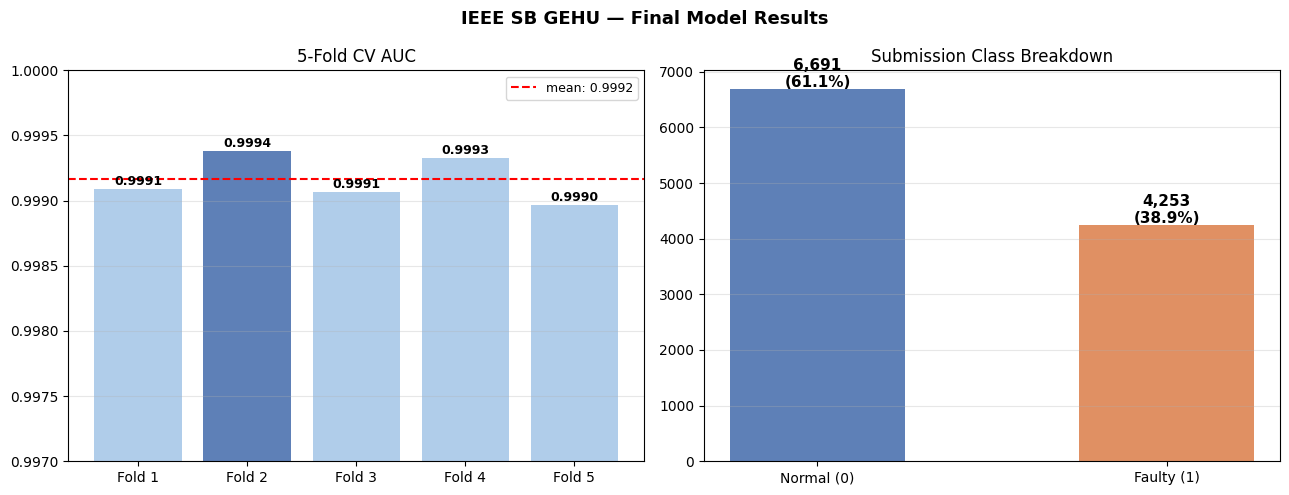


Final CV AUC : 0.9992 +/- 0.0002
Submission   : FINAL.csv (10944 rows)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("IEEE SB GEHU — Final Model Results", fontsize=13, fontweight="bold")

# fold scores
ax = axes[0]
colors = ["#4C72B0" if s == max(fold_scores) else "#A8C8E8" for s in fold_scores]
bars = ax.bar([f"Fold {i}" for i in range(1, 6)], fold_scores, color=colors, alpha=0.9)
ax.axhline(np.mean(fold_scores), color="red", linestyle="--", linewidth=1.5,
           label=f"mean: {np.mean(fold_scores):.4f}")
ax.set_ylim(0.997, 1.0)
ax.set_title("5-Fold CV AUC")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
for bar, s in zip(bars, fold_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.00003,
            f"{s:.4f}", ha="center", fontsize=9, fontweight="bold")

# submission breakdown
ax = axes[1]
counts = [(binary_preds == 0).sum(), (binary_preds == 1).sum()]
bars3  = ax.bar(["Normal (0)", "Faulty (1)"], counts,
                color=["#4C72B0", "#DD8452"], alpha=0.9, width=0.5)
for bar, c in zip(bars3, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f"{c:,}\n({c/len(test)*100:.1f}%)",
            ha="center", fontsize=11, fontweight="bold")
ax.set_title("Submission Class Breakdown")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("results.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nFinal CV AUC : {np.mean(fold_scores):.4f} +/- {np.std(fold_scores):.4f}")
print(f"Submission   : FINAL.csv ({len(submission)} rows)")